1. 在所有其他参数保持不变的情况下，更改超参数`num_hiddens`的值，并查看此超参数的变化对结果有何影响。确定此超参数的最佳值。
1. 尝试添加更多的隐藏层，并查看它对结果有何影响。
1. 改变学习速率会如何影响结果？保持模型架构和其他超参数（包括轮数）不变，学习率设置为多少会带来最好的结果？
1. 通过对所有超参数（学习率、轮数、隐藏层数、每层的隐藏单元数）进行联合优化，可以得到的最佳结果是什么？
1. 描述为什么涉及多个超参数更具挑战性。
1. 如果想要构建多个超参数的搜索方法，请想出一个聪明的策略。

In [2]:
import torch
from torch import nn
from d2l import torch as d2l
from d2l_utils import train_ch3, train_epoch_ch3, evaluate_accuracy, accuracy, predict_ch3

In [3]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

In [4]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256

W1 = nn.Parameter(torch.randn(
    num_inputs, num_hiddens, requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
W2 = nn.Parameter(torch.randn(
    num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2]

In [5]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

In [6]:
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X@W1 + b1)  # 这里“@”代表矩阵乘法
    return (H@W2 + b2)

In [7]:
loss = nn.CrossEntropyLoss(reduction='none')

epoch 10: train loss 0.3805, train acc 0.8643, test acc 0.8216


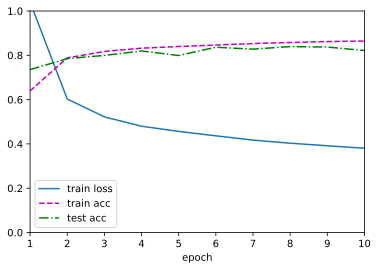

In [8]:
num_epochs, lr = 10, 0.1
updater = torch.optim.SGD(params, lr=lr)
train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)

In [9]:
predict_ch3(net, test_iter)

真实标签: [9, 2, 1, 1, 6, 1]
预测标签: [9, 2, 1, 1, 6, 1]


问题一，更改num_hiddens的值

In [10]:
import torch
from torch import nn

def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

def run_mlp_experiment(num_hiddens=256, lr=0.1, num_epochs=10):
    num_inputs, num_outputs = 784, 10

    W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens, requires_grad=True) * 0.01)
    b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
    W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs, requires_grad=True) * 0.01)
    b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

    params = [W1, b1, W2, b2]

    def net(X):
        X = X.reshape((-1, num_inputs))
        H = relu(X @ W1 + b1)
        return H @ W2 + b2

    loss = nn.CrossEntropyLoss(reduction='none')
    updater = torch.optim.SGD(params, lr=lr)

    train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)
    test_acc = evaluate_accuracy(net, test_iter)
    print(f'最终 test_acc = {test_acc:.4f}')
    return test_acc

epoch 10: train loss 0.3788, train acc 0.8661, test acc 0.8576
最终 test_acc = 0.8576

第一问结果汇总：
num_hiddens=64, test_acc=0.8449
num_hiddens=128, test_acc=0.8517
num_hiddens=256, test_acc=0.8526
num_hiddens=512, test_acc=0.8576


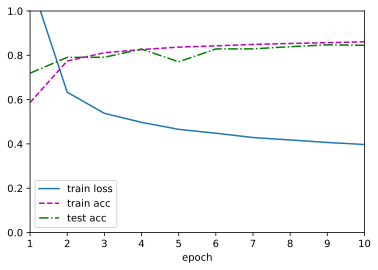

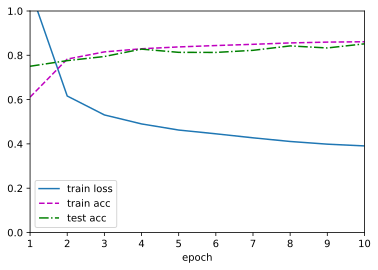

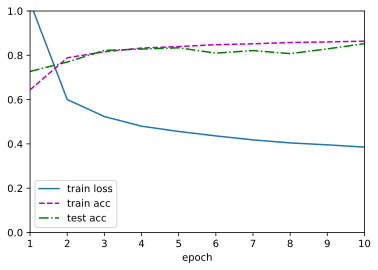

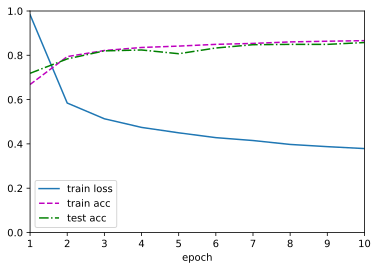

In [16]:
hidden_list = [64, 128, 256, 512]
results = []

for h in hidden_list:
    acc = run_mlp_experiment(num_hiddens=h, lr=0.1, num_epochs=10)
    results.append((h, acc))

print('\n第一问结果汇总：')
for h, acc in results:
    print(f'num_hiddens={h}, test_acc={acc:.4f}')

问题二，添加隐藏层，目前只有一个，要再加一组参数，变成784到256到128到10

In [12]:
def run_mlp_2hidden(h1=256, h2=128, lr=0.1, num_epochs=10):
    num_inputs, num_outputs = 784, 10

    W1 = nn.Parameter(torch.randn(num_inputs, h1, requires_grad=True) * 0.01)
    b1 = nn.Parameter(torch.zeros(h1, requires_grad=True))
    W2 = nn.Parameter(torch.randn(h1, h2, requires_grad=True) * 0.01)
    b2 = nn.Parameter(torch.zeros(h2, requires_grad=True))
    W3 = nn.Parameter(torch.randn(h2, num_outputs, requires_grad=True) * 0.01)
    b3 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

    params = [W1, b1, W2, b2, W3, b3]

    def net(X):
        X = X.reshape((-1, num_inputs))
        H1 = relu(X @ W1 + b1)
        H2 = relu(H1 @ W2 + b2)
        return H2 @ W3 + b3

    loss = nn.CrossEntropyLoss(reduction='none')
    updater = torch.optim.SGD(params, lr=lr)

    train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)
    test_acc = evaluate_accuracy(net, test_iter)
    print(f'最终 test_acc = {test_acc:.4f}')
    return test_acc

epoch 10: train loss 0.4012, train acc 0.8554, test acc 0.8291
最终 test_acc = 0.8291


0.8291

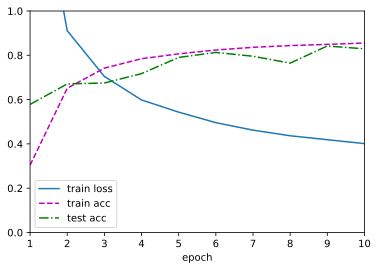

In [13]:
run_mlp_2hidden(h1=256, h2=128, lr=0.1, num_epochs=10)

问题三，改变学习率lr

epoch 10: train loss 0.3154, train acc 0.8839, test acc 0.8124
最终 test_acc = 0.8124

第三问结果汇总：
lr=0.001, test_acc=0.4437
lr=0.01, test_acc=0.7733
lr=0.05, test_acc=0.8250
lr=0.1, test_acc=0.8200
lr=0.3, test_acc=0.8124


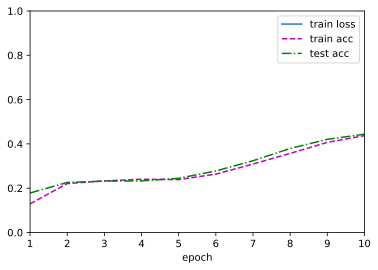

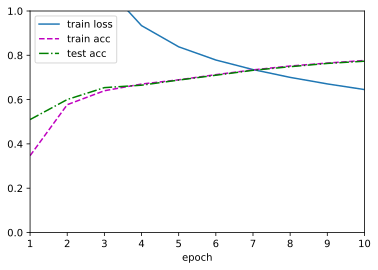

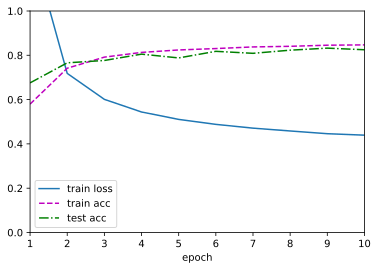

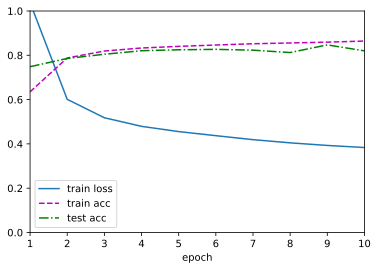

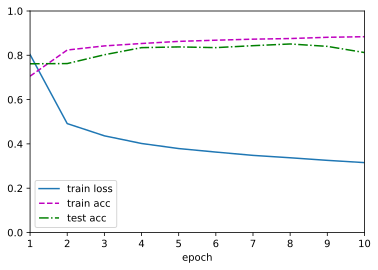

In [15]:
lr_list = [0.001, 0.01, 0.05, 0.1, 0.3]
results = []

for lr in lr_list:
    acc = run_mlp_experiment(num_hiddens=256, lr=lr, num_epochs=10)
    results.append((lr, acc))

print("\n第三问结果汇总：")
for lr, acc in results:
    print(f"lr={lr}, test_acc={acc:.4f}")

根据前面的实验，发现num_hiddens = 512时性能最好，增加隐藏层并没有带来性能提升，反而略微下降，lr = 0.05 时模型表现最好
联合优化：
隐藏层数量：1
num_hiddens = 512
learning rate = 0.05

涉及多个超参数时，不同超参数之间会相互影响，同时训练过程存在随机性

可以采用一种分阶段的调参策略，逐步缩小搜索范围
先分别调节单个超参数确定其合理范围，再在这些较优范围内进行组合搜索，从而更高效地找到较好的超参数组合